# Cabochon Data Analysis

## Project Dependencies

In [118]:
# !pip install altair

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 50.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [136]:
import re
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load cleancabochon Dataset
cabo = pd.read_csv('cleancabochon.csv')
cabo.head()

,Stone Name,New Stone Name,Stone Type 1,Stone Type 2,Size/Gage,Shape,Color,Total Price,Quantity/PKG,Unit Price,Current Qty
0,natural lone mountain turquoise,natural lone mountain turquoise,NaN,NaN,varied,oval,blue,33.00,7.0,4.71429,7
1,paloma variscite,paloma variscite,NaN,NaN,varied,oval,green,48.00,10.0,4.80000,10
2,spiny oyster,spiny oyster,NaN,NaN,varied,square,pink,80.50,30.0,2.68333,30
3,turquoise mix,turquoise mix,NaN,NaN,varied,oval,blue,148.75,33.0,4.50758,33
4,aurora opal cabochon,aurora opal cabochon,NaN,NaN,6x3.6,diamond,orange,6.78,1.0,6.78000,1


In [94]:
cabo.columns

Index(['Stone Name', 'New Stone Name', 'Stone Type 1', 'Stone Type 2',
       'Size/Gage', 'Shape', 'Color', 'Total Price', 'Quantity/PKG',
       'Unit Price', 'Current Qty', 'Qty Difference'],
      dtype='object')

## Shape Distribution

In [208]:
# Create Plotly Horizontal Bar Chart with Color
fig = px.bar(cabo, y='Shape', color='Shape', title='Shape Distribution', orientation='h')
fig.update_layout(yaxis={'categoryorder':'total ascending'}, showlegend=False, height=1000, paper_bgcolor='#EAEAEA', plot_bgcolor='#EAEAEA',)
fig.show()

In [79]:
cabo['New Stone Name'].unique()

array(['natural lone mountain turquoise', 'paloma variscite',
       'spiny oyster', 'turquoise mix', 'aurora opal cabochon',
       'oregon surfite cabachon', 'checkerboard gemstone', 'inlay mosaic',
       'inlay multi gemstone black onyx white mother of pearl',
       'inlay mosaic gemstone',
       'inlay mosaic striped natural black onyx white mother of pearl',
       'inlay natual lapis pearl', 'inlay natuaral multi gemstone',
       'inlay natural lapis pearl  checkerboard square cabochon southwestern',
       'inlay natural lapis pearl intarsia multi gemstone',
       'inlay striped natural',
       'intarsia multi gemstone inlay. natural lapis coral jasper',
       'leopardskin jasper', 'rhodonite', 'white howlite',
       'african "jade"', 'bead mix', 'autumn hickoryite', 'bamboo coral',
       'blue apatite', 'blue lace agate', 'botswana agate', 'carnelian',
       "cat's eye glass", 'chrysanthemum stone', 'chrysocolla', 'citrine',
       'crazy lace agate', 'denim lapis', '

## Color Distribution

In [100]:
cabo['Color'].unique()

array(['blue', 'green', 'pink', 'orange', 'multi-color',
       'green, red, blue, purple', 'yellow,white,', 'black onyx pearl',
       'black onyx white mother of pearl', 'lapis mother of perl',
       'lapis malachite', 'lapis pearl', 'lapis coral jasper', 'red',
       'white', 'green ', 'green, white, brown', 'brown', nan, 'multi',
       'brown/red', 'yellow', 'yellow/gold', 'brown ', 'black',
       'reddish/brown', 'silver', 'white/black', 'black/white', 'blue ',
       'white/green', 'dark sparkle', 'black/multi',
       'honey, mauve and black', 'black spotted',
       'blue, light blue, green, light green, pink', 'marble', 'mixed',
       'peach', 'light blue', 'cream luster', 'blue/white/dark blue',
       'turq', 'opal', 'turquoise bay', 'light sapphire blue', 'teal',
       'royal blue', 'autum green', 'pacific blue', 'light sapphire',
       'olive green', 'shamrock dark green', 'peridot light green',
       'olive', 'shamrock', 'light aqua', 'orange/red/yellow', 'purple'

In [205]:
# Further Clean Data

cabo['Color'] = cabo['Color'].str.strip().str.lower()
cabo['Color'] = cabo['Color'].str.replace(r'[,/]| and ', ',', regex=True)


from itertools import chain

# Drop NaN and strip whitespace from each split color
cabo_colors = (
    cabo.dropna(subset=['Color'])
        .assign(Color=cabo['Color'].str.split(','))
        .explode('Color')
)
cabo_colors['Color'] = cabo_colors['Color'].str.strip()

replacements = {
    'bluegreen': 'blue green',
    'greem': 'green',
    'blue /green iridescent': 'blue green',
    'black white': 'black/white',
    'multi': 'multi-color',
    'multi ': 'multi-color'
}
cabo_colors['Color'] = cabo_colors['Color'].replace(replacements)

cabo_colors['Color'].unique()



# Visualizations

# Color Dictionary for Visualization:
BASE_COLOR_MAP = {
    "black":    "#000000",
    "white":    "#FFFFFF",
    "gray":     "#808080",
    "grey":     "#808080",
    "silver":   "#C0C0C0",
    "gold":     "#D4AF37",
    "brown":    "#8B4513",
    "red":      "#E53935",
    "orange":   "#FB8C00",
    "yellow":   "#FDD835",
    "green":    "#43A047",
    "teal":     "#008080",
    "turquoise":"#40E0D0",
    "blue":     "#1E88E5",
    "navy":     "#001F3F",
    "purple":   "#8E24AA",
    "violet":   "#8A2BE2",
    "pink":     "#EC407A",
    "peach":    "#FFCBA4",
    "olive":    "#808000",
    "maroon":   "#800000",
    "cream":    "#FFFDD0",
    "clear":    "#DDDDDD",  # neutral
    "multi-color": "#7f7f7f",  # neutral swatch for mixed colors
}

# Optional synonyms/phrases → canonical base color
PHRASE_TO_BASE = {
    "royal blue": "blue",
    "light blue": "blue",
    "pacific blue": "blue",
    "turquoise bay": "turquoise",
    "light sapphire blue": "blue",
    "light sapphire": "blue",
    "bluegreen": "blue",
    "lapis": "blue",
    "peridot": "green",
    "shamrock": "green",
    "olive green": "olive",
    "autum green": "green",
    "teal": "teal",
    "opal": "white",
    "grey": "gray",
}

def normalize_to_base(raw: str) -> str:
    if not isinstance(raw, str) or not raw.strip():
        return "clear"
    s = raw.lower().strip()

    # unify separators and take the first token as the "dominant" color
    s = re.sub(r'\s*(/|,| and )\s*', ',', s)
    first_piece = s.split(',')[0].strip()

    # phrase maps (check longer phrases first)
    for phrase, base in sorted(PHRASE_TO_BASE.items(), key=lambda kv: -len(kv[0])):
        if phrase in first_piece:
            return base

    # direct keyword hit on base color set
    for base in BASE_COLOR_MAP.keys():
        if base in first_piece:
            return base

    # fallback for weird entries like "honey, mauve and black" (first token was "honey")
    # try scanning the whole original string for any base color
    for base in BASE_COLOR_MAP.keys():
        if base in s:
            return base

    # treat anything else as "multi" or neutral
    if "multi" in s or "varied" in s or "mixed" in s or "various" in s:
        return "multi-color"

    return "clear"  # neutral fallback

# 2) Build a discrete map from the original labels to hex by normalizing each label
unique_labels = color_counts['Color'].astype(str).unique()
label_to_hex = {}
for lbl in unique_labels:
    base = normalize_to_base(lbl)
    hex_color = BASE_COLOR_MAP.get(base, "#7f7f7f")
    label_to_hex[lbl] = hex_color

# 3) Plotly bar with category-specific colors
fig = px.bar(
    color_counts.head(15),
    y='Color', x='Count',
    color='Color',
    title='Top 15 Most Common Colors',
    orientation='h',
    color_discrete_map=label_to_hex
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False,
    paper_bgcolor='#EAEAEA',
    plot_bgcolor='#EAEAEA',
    height=1000
)

# color_counts = cabo_colors['Color'].value_counts().reset_index()
# color_counts.columns = ['Color', 'Count']

# # Plotly Horizontal bar chart of colors
# fig = px.bar(color_counts.head(15), y='Color', x='Count', color=color_dict, title='Top 15 Most Common Colors', orientation='h')
# fig.update_layout(yaxis={'categoryorder':'total ascending'}, showlegend=False, height=1000)
# fig.show()

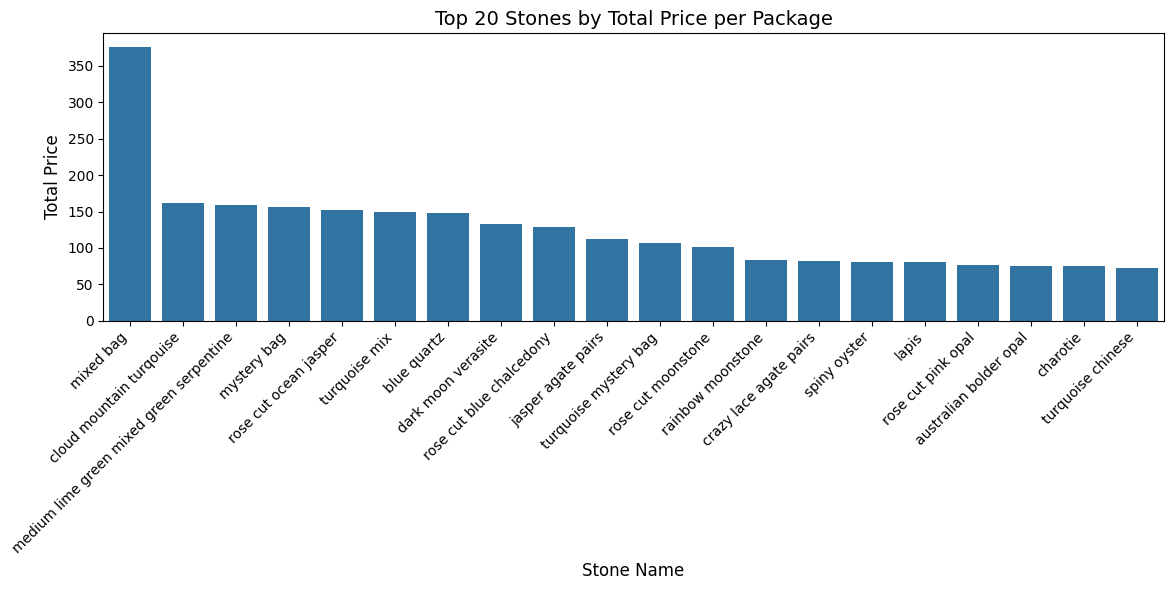

In [154]:
# Sort by Total Price (descending) and take top 20
top20 = cabo.sort_values(by='Total Price', ascending=False).head(20)

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top20,
    x='New Stone Name',
    y='Total Price',
)

# Add labels and title
plt.title('Top 20 Stones by Total Price per Package', fontsize=14)
plt.xlabel('Stone Name', fontsize=12)
plt.ylabel('Total Price', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [202]:
# Sort by Total Price (descending) and take top 20
# Create Plotly Bar Chart
top20 = top20.sort_values(by='Total Price', ascending=False).head(20)

fig = px.bar(
    top20,
    x='New Stone Name',
    y='Total Price',
    text='Total Price',  # 👈 Text shown inside bars
    title='Top 20 Stones by Total Price per Package'
)

# Format and positioning
fig.update_traces(
    texttemplate='%{text:.2f}',  # Format numbers (e.g., two decimal places)
    textposition='inside',       # 'inside' keeps labels within the bars
    insidetextanchor='end'    # vertically centered text
)

# Layout cleanup
fig.update_layout(
    xaxis={'categoryorder': 'total descending'},
    showlegend=False,
    height=1000,
    yaxis_title='Total Price',
    xaxis_title='Stone',
    paper_bgcolor='#EAEAEA',
    plot_bgcolor='#EAEAEA',
)

# Optional: Rotate x-axis labels if long
fig.update_xaxes(tickangle=90)

fig.show()


In [106]:
# diff = Quantity/PKG - Current Qty
# if diff = 0, the never sold any
# if diff == Quantity/PKG, then sold out

cabo['Qty Difference'] = cabo['Quantity/PKG'] - cabo['Current Qty']

# Grouby New Stone Name and then list top 10 most sold out
cabo.groupby('New Stone Name').sum().sort_values(by='Qty Difference').head(10)


,Stone Name,Stone Type 1,Stone Type 2,Size/Gage,Shape,Color,Total Price,Quantity/PKG,Unit Price,Current Qty,Qty Difference
New Stone Name,,,,,,,,,,,
howlite n,howlite n 8mm,0.0,0.0,8,round,marble,4.67,10.0,0.47,100,-90.0
green aventurine n round,green aventurine n round 6mmgreen aventurine ...,0.0,0.0,68,roundround,greengreen,10.07,26.0,0.79,36,-10.0
ethiopian opals,ethiopian opals,0.0,0.0,3,round,0,40.00,4.0,10.00,10,-6.0
green egyptian turquoise,green egyptian turquoise,0.0,0.0,4,round,blue,12.62,2.0,7.00,7,-5.0
black lip shell,"black lip shell , black, 8mm calibrated round,...",0.0,0.0,8,round,"black,multi",8.33,4.0,2.08,9,-5.0
medium lime green mixed green serpentine,medium lime green mixed green serpentine,0.0,0.0,0,oval,grey green,158.73,3.0,52.91,6,-3.0
inlay mosaic gemstone,"inlay mosaic gemstone, natural black onyx moth...",0.0,0.0,8,square,black onyx pearl,4.30,1.0,4.30,2,-1.0
polka dot,polka dot,0.0,0.0,0,oval,"brown,black cream",13.00,1.0,13.00,1,0.0
opal,opalopal,0.0,0.0,10.59x8.598,ovalround,blue,14.00,1.0,14.00,2,0.0


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=65165b0f-3ecd-4b4c-bb31-a66c4e6fcba5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>